# Контрольная работа: анализ данных о правонарушениях

Файл исправлен и дописан до конца. Во всех заданиях далее используется только срез данных за 2010–2013 годы.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', None)

In [2]:
# Задание 1 балл (сумма 1)
# Загрузить данные, индекс — переменная вида дата/время.
# Срезать данные за 2010–2013 годы.
# В дальнейшем используем ТОЛЬКО срезанные данные.

df = pd.read_csv('crime.csv.zip', index_col=0, parse_dates=True)
crime_df = df.loc['2010':'2013'].copy()

print('Размер исходного датафрейма:', df.shape)
print('Размер среза 2010–2013:', crime_df.shape)
print('Период среза:', crime_df.index.min(), '—', crime_df.index.max())
crime_df.head()

Размер исходного датафрейма: (273181, 21)
Размер среза 2010–2013: (176176, 21)
Период среза: 2010-07-01 00:10:00 — 2013-12-31 23:50:00


,id,state,location_raw,county_name,county_fips,fine_grained_location,police_department,driver_gender,driver_age_raw,driver_age,driver_race_raw,driver_race,violation_raw,violation,search_conducted,search_type_raw,search_type,contraband_found,stop_outcome,is_arrested,officer_id
2010-07-01 00:10:00,VT-2010-00001,VT,East Montpelier,Washington County,50023.0,COUNTY RD,MIDDLESEX VSP,M,22.0,22.0,White,White,Moving Violation,Moving violation,False,No Search Conducted,NaN,False,Citation,False,-1.562157e+09
2010-07-01 00:11:00,VT-2010-00004,VT,Whiting,Addison County,50001.0,N MAIN ST,NEW HAVEN VSP,F,18.0,18.0,White,White,Moving Violation,Moving violation,False,No Search Conducted,NaN,False,Arrest for Violation,True,-3.126844e+08
2010-07-01 00:35:00,VT-2010-00005,VT,Hardwick,Caledonia County,50005.0,i91 nb mm 62,ROYALTON VSP,M,18.0,18.0,White,White,Moving Violation,Moving violation,False,No Search Conducted,NaN,False,Written Warning,False,9.225661e+08
2010-07-01 00:44:00,VT-2010-00006,VT,Hardwick,Caledonia County,50005.0,64000 I 91 N; MM64 I 91 N,ROYALTON VSP,F,20.0,20.0,White,White,Vehicle Equipment,Equipment,False,No Search Conducted,NaN,False,Written Warning,False,-6.032327e+08
2010-07-01 01:10:00,VT-2010-00009,VT,Rochester,Windsor County,50027.0,36000 I 91 S; MM36 I 91 S,ROCKINGHAM VSP,M,24.0,24.0,Black,Black,Moving Violation,Moving violation,False,No Search Conducted,NaN,False,Written Warning,False,2.939526e+08


In [3]:
# Задание 1 балл (сумма 2)
# Построить сводную таблицу по количеству правонарушений
# в зависимости от пола водителя (driver_gender) и типа правонарушения (violation).
# NaN заменяем на 0.

gender_violation_pivot = crime_df.pivot_table(
    index='driver_gender',
    columns='violation',
    values='id',
    aggfunc='count',
    fill_value=0
)

gender_violation_pivot

violation,DUI,Equipment,Moving violation,Other,Other (non-mapped)
driver_gender,,,,,
F,136,12055,49876,2047,0
M,364,20154,87846,3697,1


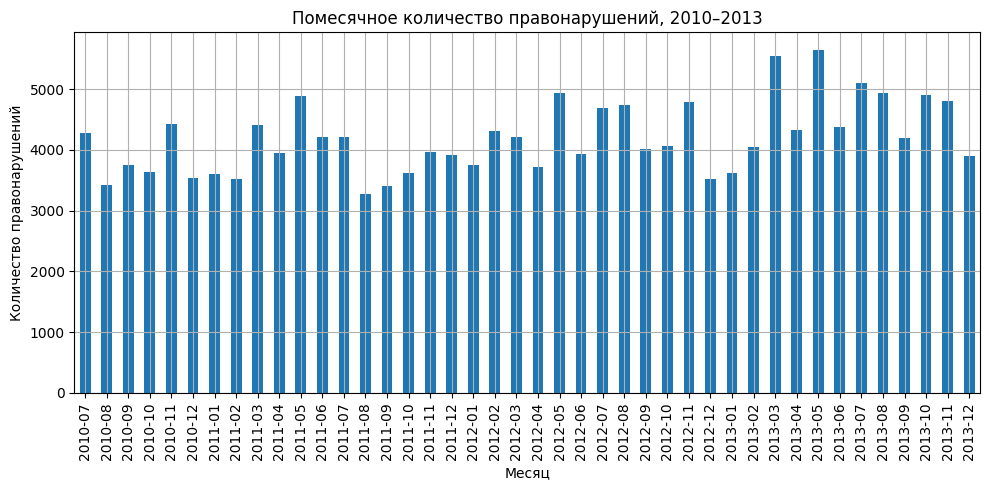

2010-07-31    4281
2010-08-31    3429
2010-09-30    3751
2010-10-31    3644
2010-11-30    4430
Freq: ME, Name: id, dtype: int64

In [4]:
# Задание 2 балла (сумма 4)
# Найти помесячное количество правонарушений и построить столбцовый график.
# Правильно: группируем именно по месяцам временного ряда, а не просто по номеру месяца.

monthly_crimes = crime_df.resample('ME')['id'].count()

ax = monthly_crimes.plot(kind='bar')
ax.set_title('Помесячное количество правонарушений, 2010–2013')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество правонарушений')
ax.set_xticklabels([date.strftime('%Y-%m') for date in monthly_crimes.index], rotation=90)
plt.tight_layout()
plt.show()

monthly_crimes.head()

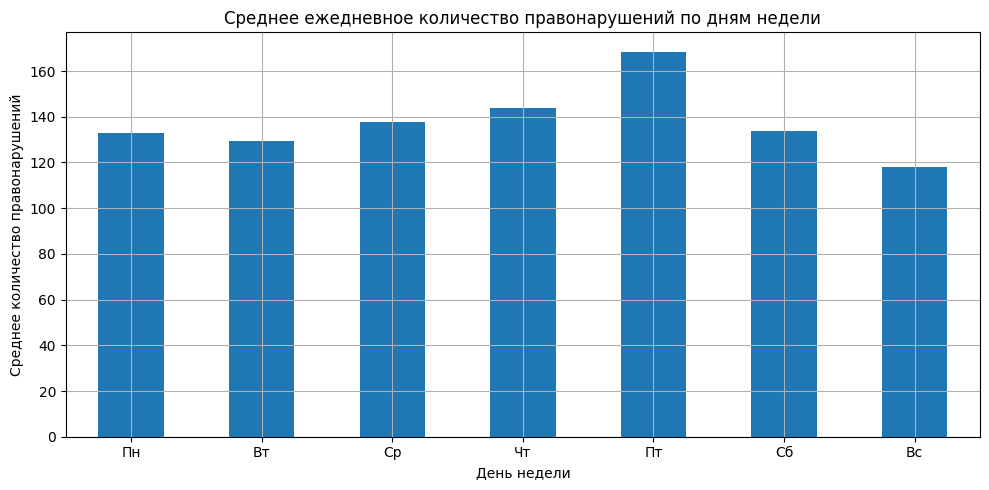

,Среднее число правонарушений
Пн,132.923497
Вт,129.289617
Ср,137.582418
Чт,143.601093
Пт,168.491803
Сб,133.775956
Вс,117.797814


In [5]:
# Задание 2 балла (сумма 6)
# Найти ежедневное количество правонарушений.
# Затем найти среднее количество правонарушений в зависимости от дня недели.
# Визуализировать результат столбцовой диаграммой.
# Столбцы подписываем Пн–Вс.

weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

daily_crimes = crime_df.resample('D')['id'].count().to_frame('crimes_count')
daily_crimes['weekday_num'] = daily_crimes.index.weekday

avg_by_weekday = (
    daily_crimes
    .groupby('weekday_num')['crimes_count']
    .mean()
    .reindex(range(7))
)
avg_by_weekday.index = weekday_names

ax = avg_by_weekday.plot(kind='bar')
ax.set_title('Среднее ежедневное количество правонарушений по дням недели')
ax.set_xlabel('День недели')
ax.set_ylabel('Среднее количество правонарушений')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

avg_by_weekday.to_frame('Среднее число правонарушений')

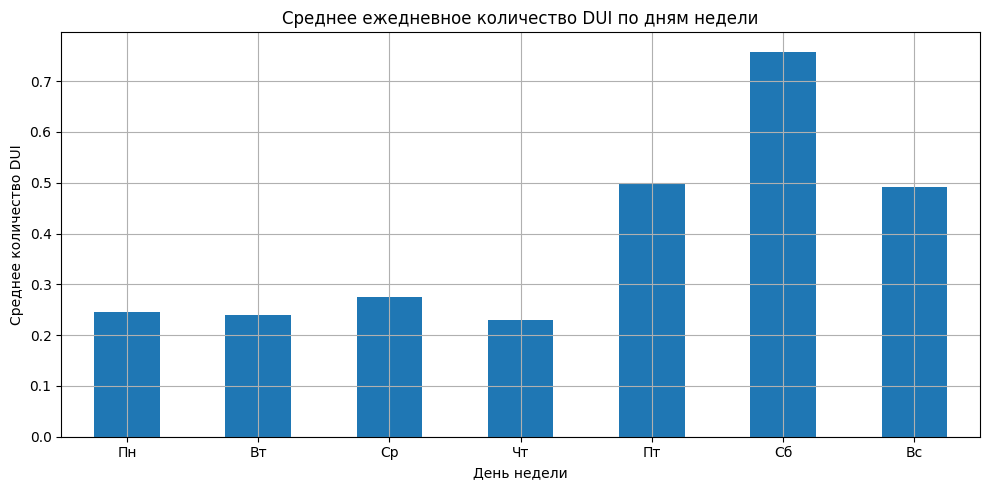

,Среднее число DUI
Пн,0.245902
Вт,0.240437
Ср,0.274725
Чт,0.230769
Пт,0.500000
Сб,0.758242
Вс,0.491803


In [6]:
# Задание 2 балла (сумма 8)
# Отобрать водителей под воздействием веществ: violation == 'DUI'
# Проверить, существует ли зависимость количества DUI от дня недели.
# Построить график и описать зависимость.

dui_df = crime_df[crime_df['violation'] == 'DUI'].copy()

dui_daily = dui_df.resample('D')['id'].count().to_frame('dui_count')
dui_daily['weekday_num'] = dui_daily.index.weekday

avg_dui_by_weekday = (
    dui_daily
    .groupby('weekday_num')['dui_count']
    .mean()
    .reindex(range(7))
)
avg_dui_by_weekday.index = weekday_names

ax = avg_dui_by_weekday.plot(kind='bar')
ax.set_title('Среднее ежедневное количество DUI по дням недели')
ax.set_xlabel('День недели')
ax.set_ylabel('Среднее количество DUI')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

avg_dui_by_weekday.to_frame('Среднее число DUI')

**Вывод по DUI и дням недели.**  
Зависимость от дня недели есть: в среднем больше всего случаев DUI приходится на **субботу**, затем заметны **пятница** и **воскресенье**. Это логично: DUI чаще встречается в конце недели и в выходные, когда люди чаще отдыхают вечером/ночью.

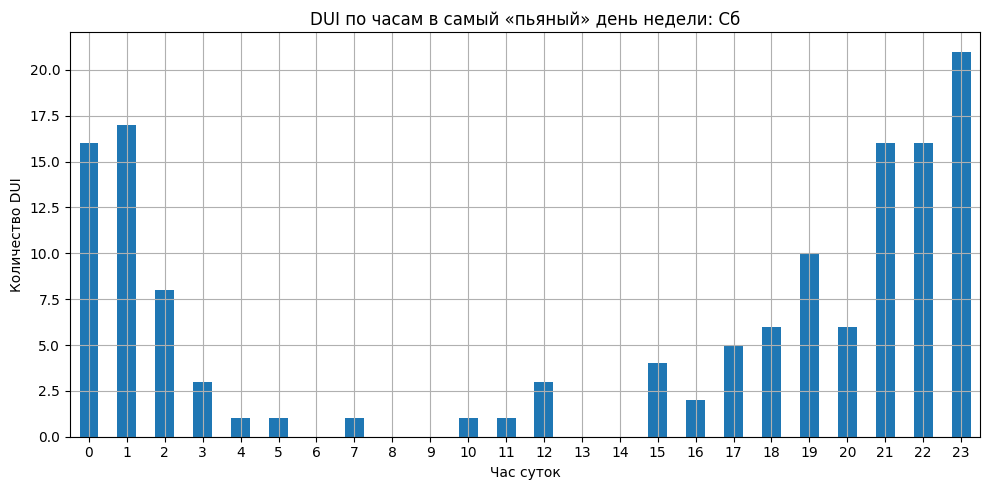

Самый «пьяный» день недели: Сб
Самый «пьяный» час: 23:00


,Количество DUI
0,16
1,17
2,8
3,3
4,1
5,1
6,0
7,1
8,0
9,0


In [7]:
# Задание 2 балла (сумма 10)
# Для самого «пьяного дня» найти самый «пьяный час».
# Визуализировать для подтверждения.

# Находим номер дня недели с максимальным средним количеством DUI.
drunkest_weekday_num = int(avg_dui_by_weekday.reset_index(drop=True).idxmax())
drunkest_weekday_name = weekday_names[drunkest_weekday_num]

# Берём только DUI в этот день недели и считаем количество по часам.
dui_drunkest_day = dui_df[dui_df.index.weekday == drunkest_weekday_num].copy()
dui_by_hour = dui_drunkest_day.groupby(dui_drunkest_day.index.hour)['id'].count().reindex(range(24), fill_value=0)

drunkest_hour = int(dui_by_hour.idxmax())

ax = dui_by_hour.plot(kind='bar')
ax.set_title(f'DUI по часам в самый «пьяный» день недели: {drunkest_weekday_name}')
ax.set_xlabel('Час суток')
ax.set_ylabel('Количество DUI')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'Самый «пьяный» день недели: {drunkest_weekday_name}')
print(f'Самый «пьяный» час: {drunkest_hour}:00')

dui_by_hour.to_frame('Количество DUI')

**Итоговый вывод.**  
Самый «пьяный» день недели — **суббота**. Внутри субботы максимум DUI приходится на **23:00**. Значит, самый рискованный период по DUI в этих данных — поздний субботний вечер.